In [1]:
!python --version

Python 3.9.23


In [7]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import pyphi

# ====================================
# 1. Generate Parity Dataset
# ====================================
def generate_parity_data(n_samples=1000, seq_len=6):
    X = []
    y = []
    for _ in range(n_samples):
        seq = np.random.randint(0, 2, size=(seq_len,))
        label = int(np.sum(seq) % 2 == 0)  # even parity = 1
        X.append(seq)
        y.append(label)
    return np.array(X), np.array(y)

X, y = generate_parity_data(1000, seq_len=6)
X_tensor = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)
y_tensor = torch.tensor(y, dtype=torch.long)

# ====================================
# 2. Define Vanilla RNN
# ====================================
class VanillaRNN(nn.Module):
    def __init__(self, input_size=1, hidden_size=2, output_size=2):
        super(VanillaRNN, self).__init__()
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, h_n = self.rnn(x)
        out = self.fc(h_n.squeeze(0))
        return out, h_n.squeeze(0)

model = VanillaRNN()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ====================================
# 3. Train the RNN
# ====================================
for epoch in range(50):
    optimizer.zero_grad()
    output, _ = model(X_tensor)
    loss = criterion(output, y_tensor)
    loss.backward()
    optimizer.step()
    if (epoch+1) % 10 == 0:
        print(f"Epoch [{epoch+1}/50], Loss: {loss.item():.4f}")

# ====================================
# 4. Build State-to-State TPM
# ====================================
state_to_index = {(0, 0): 0, (0, 1): 1, (1, 0): 2, (1, 1): 3}
index_to_state = {v: k for k, v in state_to_index.items()}
tpm = np.zeros((4, 4))

hidden_states = []
with torch.no_grad():
    for i in range(len(X_tensor)):
        _, h = model(X_tensor[i].unsqueeze(0))
        bin_h = tuple((h.squeeze(0) > 0).int().numpy())
        hidden_states.append(bin_h)

for i in range(len(hidden_states) - 1):
    s1 = state_to_index[hidden_states[i]]
    s2 = state_to_index[hidden_states[i + 1]]
    tpm[s1, s2] += 1

tpm = np.nan_to_num(tpm / tpm.sum(axis=1, keepdims=True))
print("\nTransition Probability Matrix (TPM):")
print(tpm)

# ====================================
# 5. Convert to PyPhi format (2, 2, N) = (2, 2, 2)
# ====================================
pyphi_tpm = np.zeros((2, 2, 2))
for b1 in [0, 1]:
    for b2 in [0, 1]:
        state_index = state_to_index[(b1, b2)]
        for node in [0, 1]:
            prob_on = 0.0
            for next_state_index in range(4):
                prob = tpm[state_index, next_state_index]
                b1_next, b2_next = index_to_state[next_state_index]
                if node == 0 and b1_next == 1:
                    prob_on += prob
                elif node == 1 and b2_next == 1:
                    prob_on += prob
            pyphi_tpm[b1, b2, node] = prob_on

# ====================================
# 6. Create PyPhi Network
# ====================================
connectivity = np.ones((2, 2), dtype=int)  # fully connected
network = pyphi.Network(pyphi_tpm, connectivity)

# ====================================
# 7. Compute Φ for all states
# ====================================
for state in [(0,0), (0,1), (1,0), (1,1)]:
    analysis = pyphi.compute.major_complex(network, state)
    print(f"Φ for state {state}: {analysis.phi}")


Epoch [10/50], Loss: 0.6957
Epoch [20/50], Loss: 0.6930
Epoch [30/50], Loss: 0.6922
Epoch [40/50], Loss: 0.6921
Epoch [50/50], Loss: 0.6920

Transition Probability Matrix (TPM):
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 1.]]


/var/folders/b2/pjb3rq2s7vn79xdxmx1q6mpc0000gn/T/ipykernel_83866/3537251012.py:73: RuntimeWarning: invalid value encountered in divide
  tpm = np.nan_to_num(tpm / tpm.sum(axis=1, keepdims=True))
Computing concepts:  33%|████████▎                | 1/3 [00:02<00:05,  2.63s/it]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma


                                                                                
Evaluating Φ cuts:  50%|█████████████             | 1/2 [00:01<00:01,  1.69s/it]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma

...


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma

tps://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://py


Evaluating Φ cuts:  50%|█████████████             | 1/2 [00:01<00:01,  1.74s/it]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma

Φ for state (1, 1): 0.1875


In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, LSTM, Dense
from tensorflow.keras.optimizers import Adam
import pyphi

# ====================================
# 1. Generate Parity Bit Dataset
# ====================================
def generate_parity_data(seq_length=5, num_samples=200):
    X = np.random.randint(0, 2, (num_samples, seq_length, 1))
    y = np.sum(X, axis=1) % 2  # Parity: 1 if odd, 0 if even
    return X, y

seq_length = 3
num_samples = 100
X_train, y_train = generate_parity_data(seq_length, num_samples)

# ====================================
# 2. Define Model (switch between GRU / LSTM)
# ====================================
def build_model(model_type='GRU'):
    model = Sequential()
    if model_type == 'GRU':
        model.add(GRU(2, input_shape=(seq_length, 1), activation='sigmoid', return_sequences=False))
    elif model_type == 'LSTM':
        model.add(LSTM(2, input_shape=(seq_length, 1), activation='sigmoid', return_sequences=False))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=Adam(0.01), loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Choose model_type = 'GRU' or 'LSTM'
model_type = 'GRU'
model = build_model(model_type)

# ====================================
# 3. Train Model
# ====================================
model.fit(X_train, y_train, epochs=50, verbose=0)

# ====================================
# 4. Extract Hidden States for TPM
# ====================================
# Create a new model to output the hidden layer
hidden_layer_model = tf.keras.Model(inputs=model.input, outputs=model.layers[0].output)

# Get hidden states for training data
hidden_states = hidden_layer_model.predict(X_train)

# Binarize hidden states (threshold = 0.5)
binary_states = (hidden_states > 0.5).astype(int)

# ====================================
# 5. Build TPM from transitions
# ====================================
num_nodes = binary_states.shape[1]
num_states = 2 ** num_nodes
TPM = np.zeros((num_states, num_nodes))

# Map binary state to index
def state_to_index(state):
    return int("".join(str(int(b)) for b in state), 2)

for i in range(len(binary_states) - 1):
    s_current = binary_states[i]
    s_next = binary_states[i + 1]
    TPM[state_to_index(s_current)] += s_next

# Normalize to probabilities
for i in range(num_states):
    if np.sum(TPM[i]) > 0:
        TPM[i] /= np.sum(TPM[i])

# Reshape TPM for PyPhi (state-by-node format)
TPM = TPM.reshape([2] * num_nodes + [num_nodes])

# ====================================
# 6. Create PyPhi Network and Compute Φ
# ====================================
pyphi.config.EXCLUDE_SUBSYSTEMS_WITHOUT_PURVIEW = False
connectivity = np.ones((num_nodes, num_nodes), dtype=int)
network = pyphi.Network(TPM, connectivity)

print(f"Φ values for {model_type} model:")
for state_tuple in [(0,0), (0,1), (1,0), (1,1)]:
    analysis = pyphi.compute.major_complex(network, state_tuple)
    print(f"State {state_tuple}: Φ = {analysis.phi}")


In [2]:
import numpy as np
import pandas as pd
import pyphi
# Load CSV file
tpm_df = pd.read_csv("RNN_TPM.csv", header=None)

# Convert to numpy array
tpm = tpm_df.to_numpy()
print("TPM shape:", tpm.shape)
print(tpm)


TPM shape: (32, 32)
[[1.48452224e-03 1.32961557e-03 1.78142669e-03 ... 2.34941781e-03
  8.64895567e-04 1.29088891e-05]
 [2.17254187e-03 2.52295185e-03 2.83832084e-03 ... 6.41250263e-03
  1.71700890e-03 0.00000000e+00]
 [7.04705615e-03 3.05625016e-03 4.47071304e-03 ... 6.68333712e-02
  1.46497941e-02 3.37450431e-02]
 ...
 [6.66880410e-02 5.54130597e-02 1.72758363e-01 ... 5.34359303e-05
  0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 2.79625151e-02 ... 0.00000000e+00
  3.02297461e-04 1.51148730e-04]
 [0.00000000e+00 0.00000000e+00 3.20078459e-02 ... 0.00000000e+00
  8.91583452e-05 1.78316690e-04]]


In [1]:
!python --version

Python 3.9.23


Epoch 1/40 Avg Loss=0.708177
Epoch 10/40 Avg Loss=0.291178
Epoch 20/40 Avg Loss=0.019066
Epoch 30/40 Avg Loss=0.006860
Epoch 40/40 Avg Loss=0.003772
Training complete.

TPM built (shape): (16, 16)


Computing concepts: 100%|███████████████████████| 15/15 [00:02<00:00, 12.78it/s]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma

Evaluating Φ cuts:  93%|██████████████████████▎ | 13/14 [00:02<00:00,  6.57it/s]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma

...


Computing concepts:  33%|████████▎                | 1/3 [00:01<00:03,  1.68s/it]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma


                                                                                
Evaluating Φ cuts:  50%|█████████████             | 1/2 [00:01<00:01,  1.95s/it]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma

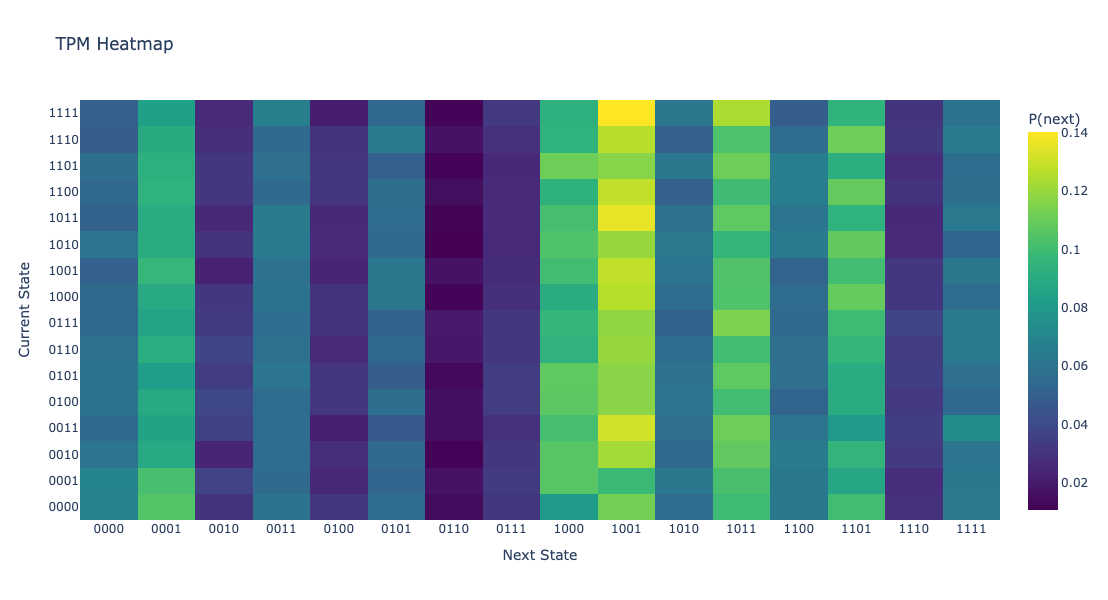

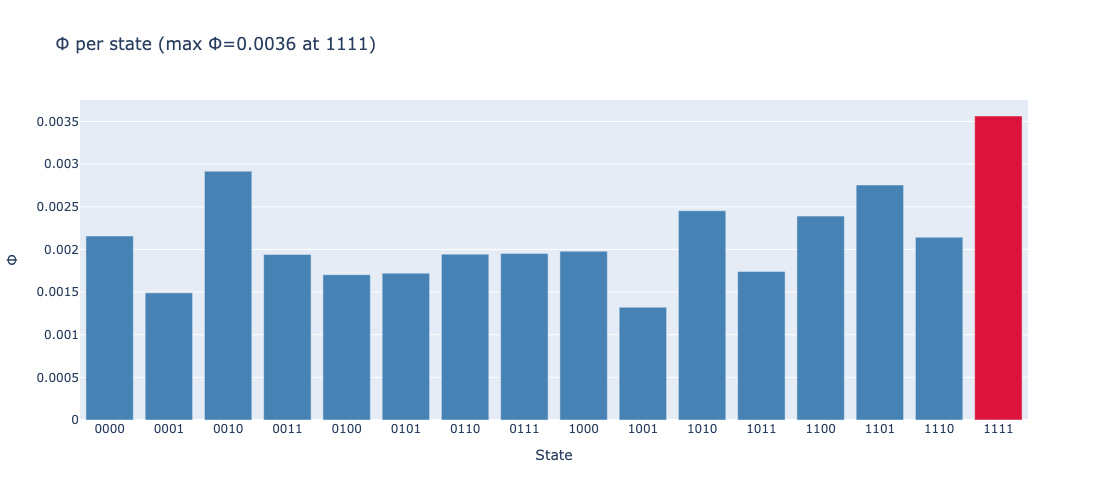

In [2]:
# ------------------------------------------------------------
# Vanilla RNN Hidden Layer Monte Carlo TPM + Φ Calculation (4 units)
# ------------------------------------------------------------

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import itertools
import pyphi
import pandas as pd
import plotly.graph_objects as go
import math

# ---------------------------- Device -------------------------
device = torch.device("cpu")

# ---------------------------- Data ---------------------------
def generate_parity_data(n_samples=2000):
    X = np.random.randint(0, 2, (n_samples, 2))
    y = np.sum(X, axis=1) % 2
    return X.astype(np.float32), y.astype(np.float32)

X, y = generate_parity_data(2000)
X_train, y_train = X[:1600], y[:1600]
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=64, shuffle=True)

# ---------------------------- RNN Model ----------------------
input_size = 2
hidden_size = 4

class RNNRegressor(nn.Module):
    def __init__(self, input_size=2, hidden_size=4):
        super().__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, h0=None):
        x = x.unsqueeze(1)  # (batch, seq=1, input_size)
        out, h = self.rnn(x, h0)
        out = self.fc(h.squeeze(0))
        return torch.sigmoid(out), h

model = RNNRegressor(input_size=input_size, hidden_size=hidden_size).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# ---------------------------- Train --------------------------
epochs = 40
for ep in range(1, epochs+1):
    model.train()
    total_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred, _ = model(xb)
        loss = criterion(pred.squeeze(), yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * xb.size(0)
    if ep % 10 == 0 or ep == 1:
        print(f"Epoch {ep}/{epochs} Avg Loss={total_loss / len(train_loader.dataset):.6f}")

print("Training complete.")

# ---------------------------- Monte Carlo TPM -----------------
n_nodes = hidden_size
states = list(itertools.product([0,1], repeat=n_nodes))
num_states = 2 ** n_nodes

mc_inputs_per_state = 800
mc_bernoulli_samples = 4
rng = np.random.RandomState(42)
tpm_counts = np.zeros((num_states, num_states), dtype=float)

with torch.no_grad():
    for i, h_state in enumerate(states):
        h_vec = np.array(h_state, dtype=np.float32)
        h0 = torch.tensor(h_vec).unsqueeze(0).unsqueeze(0).to(device)
        for _ in range(mc_inputs_per_state):
            inp = rng.randint(0,2,size=(input_size,)).astype(np.float32)
            inp_tensor = torch.tensor(inp).unsqueeze(0).unsqueeze(0).to(device)
            _, h_next = model.rnn(inp_tensor, h0)
            probs = torch.sigmoid(h_next).squeeze(0).squeeze(0).cpu().numpy()
            for _ in range(mc_bernoulli_samples):
                sample = (rng.rand(n_nodes) < probs).astype(int)
                next_idx = int("".join(map(str, sample)), 2)
                tpm_counts[i, next_idx] += 1

# Convert counts → probabilities
epsilon = 1e-8
tpm_pyphi = (tpm_counts + epsilon)
tpm_pyphi = tpm_pyphi / tpm_pyphi.sum(axis=1, keepdims=True)

print("\nTPM built (shape):", tpm_pyphi.shape)

# ---------------------------- PyPhi Setup ----------------------
connectivity = np.ones((n_nodes, n_nodes), dtype=int)
pyphi.config.VALIDATE_SUBSYSTEM_STATES = False
pyphi.config.VALIDATE_CONDITIONAL_INDEPENDENCE = False

network = pyphi.Network(tpm_pyphi, connectivity)

# ---------------------------- Compute Φ ------------------------
def idx_to_state(idx, n=n_nodes):
    return np.array(list(np.binary_repr(idx, width=n))).astype(int)

phi_results = []
for i in range(num_states):
    state = idx_to_state(i)
    try:
        subsystem = pyphi.Subsystem(network, state, tuple(range(n_nodes)))
        phi_val = pyphi.compute.phi(subsystem)
        phi_results.append((tuple(state), float(phi_val)))
        print(f"Φ for state {state} = {phi_val:.6f}")
    except Exception as e:
        print(f"⚠️ Skipping state {state}: {type(e).__name__}: {e}")
        phi_results.append((tuple(state), np.nan))

# Maximum Φ
valid_results = [(s,v) for s,v in phi_results if not (isinstance(v,float) and np.isnan(v))]
if valid_results:
    max_state, max_phi = max(valid_results, key=lambda x: x[1])
    print("\nMost integrated state (max Φ):", max_state)
    print(f"Maximum Φ = {max_phi:.6f}")
    major_complex = pyphi.compute.major_complex(network, np.array(max_state))
    print(f"Major complex Φ = {major_complex.phi:.6f}")
    print("Nodes in major complex:", major_complex.subsystem.node_indices)
else:
    print("No valid Φ computed.")

# ---------------------------- Visualization --------------------
def get_state_labels(tpm):
    n_states = tpm.shape[0]
    n_nodes = int(round(math.log2(n_states)))
    return [format(i, f"0{n_nodes}b") for i in range(n_states)]

def phi_results_to_df(phi_results):
    rows = [[ "".join(str(int(x)) for x in s), phi ] for s, phi in phi_results]
    return pd.DataFrame(rows, columns=["state","phi"])

def plot_tpm_heatmap(tpm, title="TPM Heatmap"):
    state_labels = get_state_labels(tpm)
    hover = [[f"from {state_labels[i]} → {state_labels[j]}<br>P={float(p):.6f}"
              for j,p in enumerate(row)] for i,row in enumerate(tpm)]
    fig = go.Figure(data=go.Heatmap(
        z=tpm, x=state_labels, y=state_labels, text=hover, hoverinfo="text",
        colorscale="Viridis", colorbar=dict(title="P(next)")))
    fig.update_layout(title=title, xaxis_title="Next State", yaxis_title="Current State", height=600, width=700)
    return fig

def plot_phi(phi_df, title="Φ per state"):
    max_phi_row = phi_df.loc[phi_df["phi"].idxmax()]
    highlight_state = max_phi_row["state"]
    fig = go.Figure(data=[go.Bar(
        x=phi_df["state"], y=phi_df["phi"],
        marker=dict(color=[ 'crimson' if s==highlight_state else 'steelblue' for s in phi_df["state"]]),
        hovertemplate="State=%{x}<br>Φ=%{y:.6f}<extra></extra>"
    )])
    fig.update_layout(title=f"{title} (max Φ={max_phi_row['phi']:.4f} at {highlight_state})",
                      xaxis_title="State", yaxis_title="Φ", height=500, width=700)
    return fig

# Convert φ results to DataFrame
phi_df = phi_results_to_df(phi_results)

# Plot TPM heatmap
fig_tpm = plot_tpm_heatmap(tpm_pyphi)
fig_tpm.show()

# Plot Φ per state
fig_phi = plot_phi(phi_df)
fig_phi.show()


In [3]:
# Save summary
df = pd.DataFrame(phi_results, columns=['state','phi'])
df['state_str'] = df['state'].apply(lambda s: ''.join(map(str,s)))
df = df.set_index('state_str')[['phi']].sort_index()
df.to_csv('GRU_phi_hidden4_summary.csv')
print("\nSaved φ summary to ./RNN_phi_hidden4_summary.csv")



Saved φ summary to ./RNN_phi_hidden4_summary.csv


In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import itertools
import pyphi
import matplotlib.pyplot as plt

# ---------------------------- Device -------------------------
device = torch.device("cpu")

# ---------------------------- Dataset ------------------------
def generate_parity_data(n_samples=2000):
    X = np.random.randint(0, 2, (n_samples, 2))
    y = np.sum(X, axis=1) % 2
    return X.astype(np.float32), y.astype(np.float32)

X, y = generate_parity_data(2000)
X_train, y_train = X[:1600], y[:1600]
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=64, shuffle=True)

# ---------------------------- RNN Model ----------------------
input_size = 2
hidden_size = 4

class RNNRegressor(nn.Module):
    def __init__(self, input_size=2, hidden_size=4):
        super().__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, h0=None):
        x = x.unsqueeze(1)
        out, h = self.rnn(x, h0)
        out = self.fc(h.squeeze(0))
        return torch.sigmoid(out), h

model = RNNRegressor(input_size=input_size, hidden_size=hidden_size).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# ---------------------------- PyPhi Setup --------------------
n_nodes = hidden_size
states = list(itertools.product([0,1], repeat=n_nodes))
num_states = 2 ** n_nodes
connectivity = np.ones((n_nodes, n_nodes), dtype=int)
pyphi.config.VALIDATE_SUBSYSTEM_STATES = False
pyphi.config.VALIDATE_CONDITIONAL_INDEPENDENCE = False

# ---------------------------- Monte Carlo & Φ Functions -------------------
def monte_carlo_tpm(model, n_nodes, states, mc_inputs_per_state=200, mc_bernoulli_samples=4):
    tpm_counts = np.zeros((2**n_nodes, 2**n_nodes))
    rng = np.random.RandomState(42)
    with torch.no_grad():
        for i, h_state in enumerate(states):
            h0 = torch.tensor(np.array(h_state, dtype=np.float32)).unsqueeze(0).unsqueeze(0).to(device)
            for _ in range(mc_inputs_per_state):
                inp = rng.randint(0,2,size=(input_size,)).astype(np.float32)
                inp_tensor = torch.tensor(inp).unsqueeze(0).unsqueeze(0).to(device)
                _, h_next = model.rnn(inp_tensor, h0)
                probs = torch.sigmoid(h_next).squeeze(0).squeeze(0).cpu().numpy()
                for _ in range(mc_bernoulli_samples):
                    sample = (rng.rand(n_nodes) < probs).astype(int)
                    next_idx = int("".join(map(str, sample)), 2)
                    tpm_counts[i, next_idx] += 1
    tpm_pyphi = tpm_counts + 1e-8
    tpm_pyphi /= tpm_pyphi.sum(axis=1, keepdims=True)
    return tpm_pyphi

def compute_average_phi(tpm, n_nodes):
    network = pyphi.Network(tpm, np.ones((n_nodes,n_nodes), dtype=int))
    phi_values = []
    for i in range(2**n_nodes):
        state = np.array(list(np.binary_repr(i, width=n_nodes))).astype(int)
        try:
            subsystem = pyphi.Subsystem(network, state, tuple(range(n_nodes)))
            phi_val = pyphi.compute.phi(subsystem)
            phi_values.append(phi_val)
        except:
            phi_values.append(0.0)  # skip unreachable states
    return np.mean(phi_values)

# ---------------------------- Training + Φ per Epoch ----------------------
epochs = 30
epoch_phi = []

for ep in range(1, epochs+1):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred, _ = model(xb)
        loss = criterion(pred.squeeze(), yb)
        loss.backward()
        optimizer.step()
    
    # Compute Φ at the end of the epoch
    model.eval()
    tpm = monte_carlo_tpm(model, n_nodes, states, mc_inputs_per_state=200, mc_bernoulli_samples=4)
    avg_phi = compute_average_phi(tpm, n_nodes)
    epoch_phi.append(avg_phi)
    print(f"Epoch {ep} -> Average Φ = {avg_phi:.6f}")

# ---------------------------- Plot Epoch vs Φ ------------------------------
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), epoch_phi, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Average Φ")
plt.title("RNN Hidden Layer Integration (Epoch vs Φ)")
plt.grid(True)
plt.show()



Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma

Evaluating Φ cuts: 100%|████████████████████████| 14/14 [00:03<00:00,  8.28it/s]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma

Computing concepts:  27%|██████▍                 | 4/15 [00:01<00:03,  2.77it/s]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma

...

Evaluating Φ cuts:  71%|█████████████████▏      | 10/14 [00:03<00:00,  4.26it/s]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma

Computing concepts:  73%|████████████████▊      | 11/15 [00:02<00:00,  5.97it/s]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma

Evaluating Φ cuts:   0%|                                 | 0/14 [00:00<?, ?it/s]

Computing concepts: 100%|███████████████████████| 15/15 [00:04<00:00,  4.87it/s]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma

rchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  ht

Evaluating Φ cuts:  79%|██████████████████▊     | 11/14 [00:04<00:00,  3.67it/s]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma

...

Computing concepts:  93%|█████████████████████▍ | 14/15 [00:03<00:00,  7.06it/s]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma

Evaluating Φ cuts: 100%|████████████████████████| 14/14 [00:05<00:00,  5.06it/s]


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Marchman R, Tononi G.
  (2018). PyPhi: A toolbox for integrated information theory.
  PLOS Computational Biology 14(7): e1006343.
  https://doi.org/10.1371/journal.pcbi.1006343

Documentation is available online (or with the built-in `help()` function):
  https://pyphi.readthedocs.io

To report issues, please use the issue tracker on the GitHub repository:
  https://github.com/wmayner/pyphi

For general discussion, you are welcome to join the pyphi-users group:
  https://groups.google.com/forum/#!forum/pyphi-users

To suppress this message, either:
  - Set `WELCOME_OFF: true` in your `pyphi_config.yml` file, or
  - Set the environment variable PYPHI_WELCOME_OFF to any value in your shell:
        export PYPHI_WELCOME_OFF='yes'


Welcome to PyPhi!

If you use PyPhi in your research, please cite the paper:

  Mayner WGP, Marshall W, Albantakis L, Findlay G, Ma

Epoch 10 -> Big Φ = 0.016228


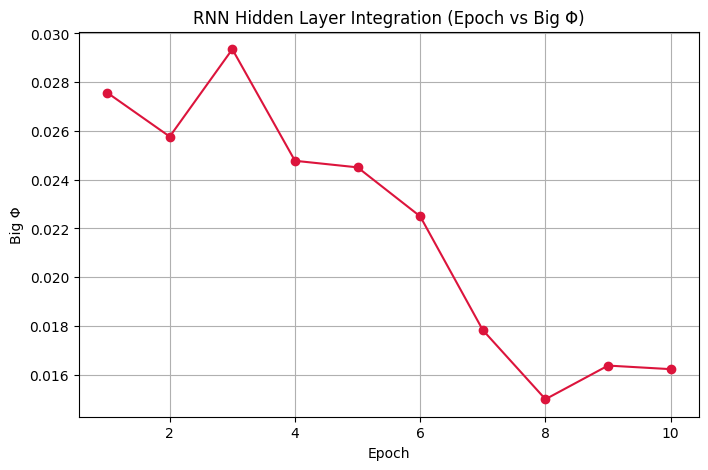

Saved data to epoch_vs_big_phi.csv


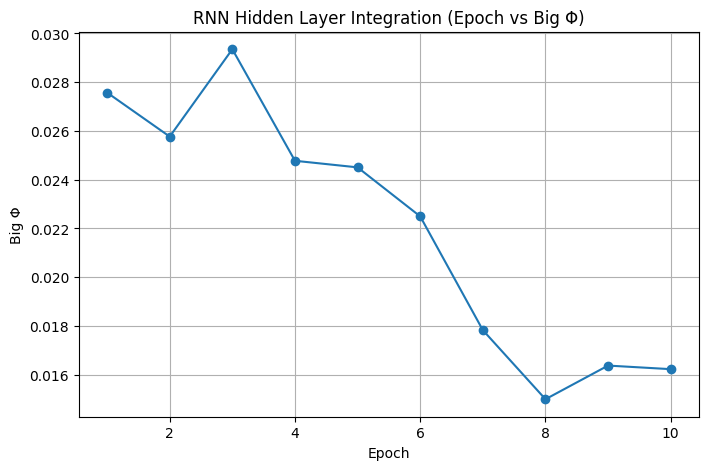

Saved plot to epoch_vs_big_phi.png


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import itertools
import pyphi
import matplotlib.pyplot as plt

# ---------------------------- Device -------------------------
device = torch.device("cpu")

# ---------------------------- Dataset ------------------------
def generate_parity_data(n_samples=2000):
    X = np.random.randint(0, 2, (n_samples, 2))
    y = np.sum(X, axis=1) % 2
    return X.astype(np.float32), y.astype(np.float32)

X, y = generate_parity_data(2000)
X_train, y_train = X[:1600], y[:1600]
train_loader = DataLoader(TensorDataset(torch.tensor(X_train), torch.tensor(y_train)), batch_size=64, shuffle=True)

# ---------------------------- RNN Model ----------------------
input_size = 2
hidden_size = 4

class RNNRegressor(nn.Module):
    def __init__(self, input_size=2, hidden_size=4):
        super().__init__()
        self.hidden_size = hidden_size
        self.rnn = nn.RNN(input_size, hidden_size, batch_first=True, nonlinearity='tanh')
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x, h0=None):
        x = x.unsqueeze(1)  # add sequence dimension
        out, h = self.rnn(x, h0)
        out = self.fc(h.squeeze(0))
        return torch.sigmoid(out), h

model = RNNRegressor(input_size=input_size, hidden_size=hidden_size).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# ---------------------------- PyPhi Setup --------------------
n_nodes = hidden_size
states = list(itertools.product([0,1], repeat=n_nodes))
num_states = 2 ** n_nodes
connectivity = np.ones((n_nodes, n_nodes), dtype=int)
pyphi.config.VALIDATE_SUBSYSTEM_STATES = False
pyphi.config.VALIDATE_CONDITIONAL_INDEPENDENCE = False

# ---------------------------- Monte Carlo TPM -----------------
def monte_carlo_tpm(model, n_nodes, states, mc_inputs_per_state=200, mc_bernoulli_samples=4):
    tpm_counts = np.zeros((2**n_nodes, 2**n_nodes))
    rng = np.random.RandomState(42)
    with torch.no_grad():
        for i, h_state in enumerate(states):
            h0 = torch.tensor(np.array(h_state, dtype=np.float32)).unsqueeze(0).unsqueeze(0).to(device)
            for _ in range(mc_inputs_per_state):
                inp = rng.randint(0,2,size=(input_size,)).astype(np.float32)
                inp_tensor = torch.tensor(inp).unsqueeze(0).unsqueeze(0).to(device)
                _, h_next = model.rnn(inp_tensor, h0)
                probs = torch.sigmoid(h_next).squeeze(0).squeeze(0).cpu().numpy()
                for _ in range(mc_bernoulli_samples):
                    sample = (rng.rand(n_nodes) < probs).astype(int)
                    next_idx = int("".join(map(str, sample)), 2)
                    tpm_counts[i, next_idx] += 1
    tpm_pyphi = tpm_counts + 1e-8
    tpm_pyphi /= tpm_pyphi.sum(axis=1, keepdims=True)
    return tpm_pyphi

# ---------------------------- Compute max Φ (big phi) -----------------
def compute_max_phi(tpm, n_nodes):
    network = pyphi.Network(tpm, np.ones((n_nodes,n_nodes), dtype=int))
    phi_values = []
    for i in range(2**n_nodes):
        state = np.array(list(np.binary_repr(i, width=n_nodes))).astype(int)
        try:
            subsystem = pyphi.Subsystem(network, state, tuple(range(n_nodes)))
            phi_val = pyphi.compute.phi(subsystem)
            phi_values.append(phi_val)
        except:
            phi_values.append(0.0)
    return max(phi_values)

# ---------------------------- Training + Big Phi per Epoch -----------------
epochs = 10
epoch_big_phi = []

for ep in range(1, epochs+1):
    model.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        pred, _ = model(xb)
        loss = criterion(pred.squeeze(), yb)
        loss.backward()
        optimizer.step()
    
    # Compute TPM and big Phi
    model.eval()
    tpm = monte_carlo_tpm(model, n_nodes, states, mc_inputs_per_state=200, mc_bernoulli_samples=4)
    big_phi = compute_max_phi(tpm, n_nodes)
    epoch_big_phi.append(big_phi)
    print(f"Epoch {ep} -> Big Φ = {big_phi:.6f}")

# ---------------------------- Plot Epoch vs Big Phi ----------------------
plt.figure(figsize=(8,5))
plt.plot(range(1, epochs+1), epoch_big_phi, marker='o', color='crimson')
plt.xlabel("Epoch")
plt.ylabel("Big Φ")
plt.title("RNN Hidden Layer Integration (Epoch vs Big Φ)")
plt.grid(True)
plt.show()

# ---------------------------- Save Data ----------------------------
import numpy as np

epochs_arr = np.arange(1, epochs + 1)
phi_arr = np.array(epoch_big_phi)

np.savetxt(
    "epoch_vs_big_phi.csv",
    np.column_stack((epochs_arr, phi_arr)),
    delimiter=",",
    header="epoch,big_phi",
    comments=""
)

print("Saved data to epoch_vs_big_phi.csv")

# ---------------------------- Save Plot ----------------------------
plt.figure(figsize=(8,5))
plt.plot(epochs_arr, phi_arr, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Big Φ")
plt.title("RNN Hidden Layer Integration (Epoch vs Big Φ)")
plt.grid(True)

plt.savefig("epoch_vs_big_phi.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved plot to epoch_vs_big_phi.png")



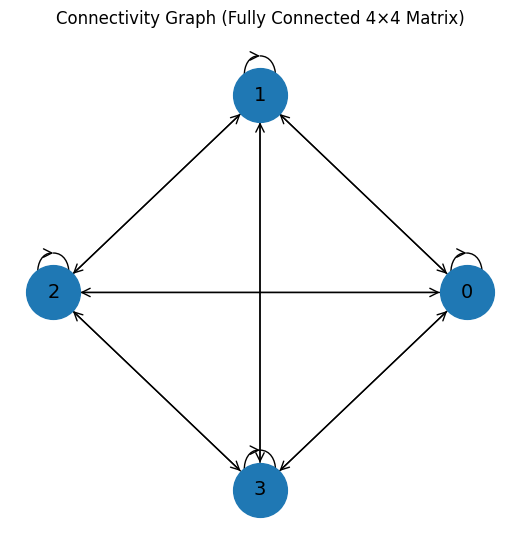

In [2]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Number of hidden nodes
n_nodes = 4

# Fully connected adjacency matrix (same as your pyphi connectivity)
connectivity = np.ones((n_nodes, n_nodes), dtype=int)

# Create directed graph
G = nx.DiGraph()

# Add nodes
for i in range(n_nodes):
    G.add_node(i)

# Add edges according to matrix
for i in range(n_nodes):
    for j in range(n_nodes):
        if connectivity[i, j] == 1:
            G.add_edge(i, j)

# Draw graph
plt.figure(figsize=(5, 5))
pos = nx.circular_layout(G)     # circular visualization
nx.draw(
    G, pos,
    with_labels=True,
    arrows=True,
    node_size=1500,
    font_size=14,
    arrowstyle='->',
    arrowsize=15
)

plt.title("Connectivity Graph (Fully Connected 4×4 Matrix)")
plt.show()


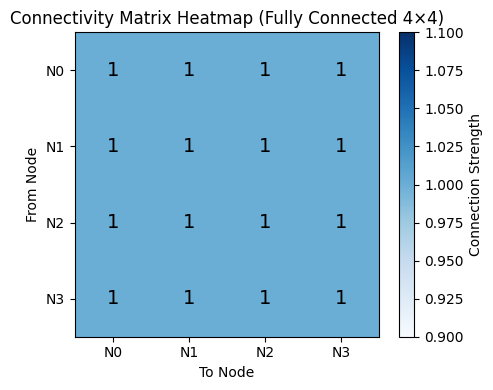

In [4]:
import numpy as np
import matplotlib.pyplot as plt

n_nodes = 4
connectivity = np.ones((n_nodes, n_nodes), dtype=int)

plt.figure(figsize=(5,4))
plt.imshow(connectivity, cmap="Blues", interpolation="nearest")

# Show value labels inside squares
for i in range(n_nodes):
    for j in range(n_nodes):
        plt.text(j, i, connectivity[i, j],
                 ha='center', va='center', color='black', fontsize=14)

plt.title("Connectivity Matrix Heatmap (Fully Connected 4×4)")
plt.xlabel("To Node")
plt.ylabel("From Node")
plt.colorbar(label="Connection Strength")
plt.xticks(range(n_nodes), [f"N{j}" for j in range(n_nodes)])
plt.yticks(range(n_nodes), [f"N{i}" for i in range(n_nodes)])
plt.tight_layout()
plt.show()

